# COMP 5130 Project
## Undergraduate Group 21 - Elizabeth Casey and Maddie Larkin

Project Paper -  node2vec: Scalable Feature Learning for Networks


In [ ]:
!pip install networkx gensim scipy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 40.0 MB/s eta 0:00:00


 ### Load Dataset
 BlogCatalog


In [ ]:
!wget https://datasets.syr.edu/uploads/1252092625/BlogCatalog-dataset.zip
!unzip BlogCatalog-dataset.zip

--2026-04-06 22:39:41--  https://datasets.syr.edu/uploads/1252092625/BlogCatalog-dataset.zip
Resolving datasets.syr.edu (datasets.syr.edu)... 128.230.247.57
Connecting to datasets.syr.edu (datasets.syr.edu)|128.230.247.57|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13430637 (13M) [application/zip]
Saving to: ‘BlogCatalog-dataset.zip’

BlogCatalog-dataset 100%[===================>]  12.81M  17.2MB/s    in 0.7s    

2026-04-06 22:39:42 (17.2 MB/s) - ‘BlogCatalog-dataset.zip’ saved [13430637/13430637]

Archive:  BlogCatalog-dataset.zip
   creating: BlogCatalog-dataset/
   creating: BlogCatalog-dataset/data/
  inflating: BlogCatalog-dataset/data/edges.csv  
  inflating: BlogCatalog-dataset/data/nodes.csv  
  inflating: BlogCatalog-dataset/readme.txt  


In [ ]:
import networkx as nx
import numpy as np
import random
import time
from collections import defaultdict

# ── Load full graph ────────────────────────────────────────────────────────────
G_full = nx.read_edgelist(
    "BlogCatalog-dataset/data/edges.csv",
    delimiter=",",
    nodetype=int
)
print(f"Full graph  — Nodes: {G_full.number_of_nodes():,}  Edges: {G_full.number_of_edges():,}")

# ── Small subgraph for effectiveness / efficiency tests ────────────────────────
# Sample a connected subgraph via BFS from a high-degree seed node.
# 3 000 nodes is large enough to be meaningful but runs in minutes.
SUBGRAPH_SIZE = 1500
seed_node = max(G_full.degree, key=lambda x: x[1])[0]   # highest-degree node
bfs_nodes = list(nx.bfs_tree(G_full, seed_node).nodes())[:SUBGRAPH_SIZE]
G = G_full.subgraph(bfs_nodes).copy()

# Re-label nodes 0…N-1 so array indexing is safe
node_mapping   = {old: new for new, old in enumerate(G.nodes())}
G = nx.relabel_nodes(G, node_mapping)

print(f"Small graph — Nodes: {G.number_of_nodes():,}  Edges: {G.number_of_edges():,}")

Full graph  — Nodes: 88,784  Edges: 2,093,195
Small graph — Nodes: 1,500  Edges: 18,761


In [ ]:
# ── Load ground-truth labels (group memberships) ──────────────────────────────
# groups-edges.csv maps node_id → group_id (multi-label)
label_dict = defaultdict(list)
with open("BlogCatalog-dataset/data/edges.csv") as f:
    for line in f:
        parts = line.strip().split(",")
        if len(parts) == 2:
            node, group = int(parts[0]), int(parts[1])
            if node in node_mapping:           # only keep subgraph nodes
                label_dict[node_mapping[node]].append(group)

num_nodes  = G.number_of_nodes()
all_groups = sorted({g for gs in label_dict.values() for g in gs})
group_idx  = {g: i for i, g in enumerate(all_groups)}
num_labels = len(all_groups)

labels = np.zeros((num_nodes, num_labels), dtype=np.int8)
for node, groups in label_dict.items():
    for g in groups:
        labels[node][group_idx[g]] = 1

labeled_mask = labels.sum(axis=1) > 0
print(f"Label matrix: {labels.shape}  |  Labeled nodes: {labeled_mask.sum():,}  |  Groups: {num_labels}")

Label matrix: (1500, 40604)  |  Labeled nodes: 1,500  |  Groups: 40604


### node2vec Biased Random Walk

In [ ]:
def node2vec_walk(start_node, walk_length, p, q, neighbors_list, neighbors_set):
    """Single biased random walk from start_node."""
    walk = [start_node]
    inv_p = 1.0 / p
    inv_q = 1.0 / q

    while len(walk) < walk_length:
        cur  = walk[-1]
        nbrs = neighbors_list[cur]
        if not nbrs:
            break

        if len(walk) == 1:
            walk.append(random.choice(nbrs))
        else:
            prev      = walk[-2]
            prev_set  = neighbors_set[prev]
            # Vectorised probability assignment
            probs = np.where(
                np.array(nbrs) == prev,
                inv_p,
                np.fromiter(
                    (1.0 if n in prev_set else inv_q for n in nbrs),
                    dtype=np.float64, count=len(nbrs)
                )
            )
            probs /= probs.sum()
            walk.append(np.random.choice(nbrs, p=probs))

    return [str(n) for n in walk]


def generate_walks(G, num_walks, walk_length, p, q):
    """Generate all random walks; precompute neighbour structures once."""
    nodes          = list(G.nodes())
    neighbors_list = {n: list(G.neighbors(n)) for n in nodes}   # list for choice
    neighbors_set  = {n: set(G.neighbors(n))  for n in nodes}   # set for O(1) lookup

    walks = []
    for _ in range(num_walks):
        random.shuffle(nodes)
        for node in nodes:
            walks.append(
                node2vec_walk(node, walk_length, p, q, neighbors_list, neighbors_set)
            )
    return walks

### Train Embeddings

In [ ]:
from gensim.models import Word2Vec

def train_node2vec(G, p=1, q=1, dimensions=128, walk_length=40, num_walks=10):
    """
    Train node2vec embeddings.
    Default hyperparameters match the original paper (d=128, l=40, r=10).
    Reduced defaults are used in the experiment loop for speed.
    """
    walks = generate_walks(G, num_walks=num_walks, walk_length=walk_length, p=p, q=q)

    model = Word2Vec(
        sentences=walks,
        vector_size=dimensions,
        window=10,          # context window (paper default)
        min_count=0,
        sg=1,               # skip-gram
        workers=4,
        epochs=1            # one pass is sufficient for large walk corpora
    )

    # Safe retrieval: use the node's string key, default to zeros if missing
    num_nodes  = G.number_of_nodes()
    zero_vec   = np.zeros(dimensions)
    embeddings = np.array([
        model.wv[str(i)] if str(i) in model.wv else zero_vec
        for i in range(num_nodes)
    ])
    return embeddings

### Classification & Evaluation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

def evaluate_embeddings(embeddings, labels, test_size=0.3):
    """
    Evaluate node embeddings via multi-label logistic regression.
    Only uses nodes that have at least one label (standard protocol).
    Returns (micro_f1, macro_f1).
    """
    mask = labels.sum(axis=1) > 0
    X, y = embeddings[mask], labels[mask]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs'),
        n_jobs=-1   # parallelise across label classifiers
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    micro = f1_score(y_test, y_pred, average='micro', zero_division=0)
    macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    return micro, macro

### Experiment

In [ ]:
import pandas as pd

# Reduced walk params keep runtime reasonable on the small subgraph
# while still producing meaningful embeddings.
WALK_LENGTH = 20
NUM_WALKS   = 3
DIMENSIONS  = 64

param_grid = [
    (1,    1   ),   # DeepWalk baseline
    (0.25, 4   ),   # DFS / homophily
    (4,    0.25),   # BFS / structural
]

results = []

for p, q in param_grid:
    print(f"\n{'='*50}")
    print(f"  p={p}, q={q}")
    print(f"{'='*50}")

    t0 = time.time()
    embeddings      = train_node2vec(G, p=p, q=q,
                                     dimensions=DIMENSIONS,
                                     walk_length=WALK_LENGTH,
                                     num_walks=NUM_WALKS)
    embed_time = time.time() - t0

    t1 = time.time()
    micro, macro    = evaluate_embeddings(embeddings, labels)
    eval_time  = time.time() - t1

    total = embed_time + eval_time

    print(f"  Micro-F1 : {micro:.4f}")
    print(f"  Macro-F1 : {macro:.4f}")
    print(f"  Embed time : {embed_time:.1f}s  |  Eval time: {eval_time:.1f}s  |  Total: {total:.1f}s")

    results.append({
        "p": p, "q": q,
        "Micro-F1": round(micro, 4),
        "Macro-F1": round(macro, 4),
        "Embed Time (s)": round(embed_time, 1),
        "Eval Time (s)" : round(eval_time, 1),
        "Total Time (s)": round(total, 1),
    })

df_results = pd.DataFrame(results)
print("\n" + df_results.to_string(index=False))


  p=1, q=1
  Micro-F1 : 0.0435
  Macro-F1 : 0.0003
  Embed time : 8.6s  |  Eval time: 170.2s  |  Total: 178.9s

  p=0.25, q=4
  Micro-F1 : 0.0444
  Macro-F1 : 0.0003
  Embed time : 9.9s  |  Eval time: 160.9s  |  Total: 170.8s

  p=4, q=0.25
  Micro-F1 : 0.0419
  Macro-F1 : 0.0003
  Embed time : 7.3s  |  Eval time: 162.4s  |  Total: 169.7s

   p    q  Micro-F1  Macro-F1  Embed Time (s)  Eval Time (s)  Total Time (s)
1.00 1.00    0.0435    0.0003             8.6          170.2           178.9
0.25 4.00    0.0444    0.0003             9.9          160.9           170.8
4.00 0.25    0.0419    0.0003             7.3          162.4           169.7


### Results and Evaluation

In [ ]:
df_results

,p,q,Micro-F1,Macro-F1,Embed Time (s),Eval Time (s),Total Time (s)
0,1.00,1.00,0.0435,0.0003,8.6,170.2,178.9
1,0.25,4.00,0.0444,0.0003,9.9,160.9,170.8
2,4.00,0.25,0.0419,0.0003,7.3,162.4,169.7


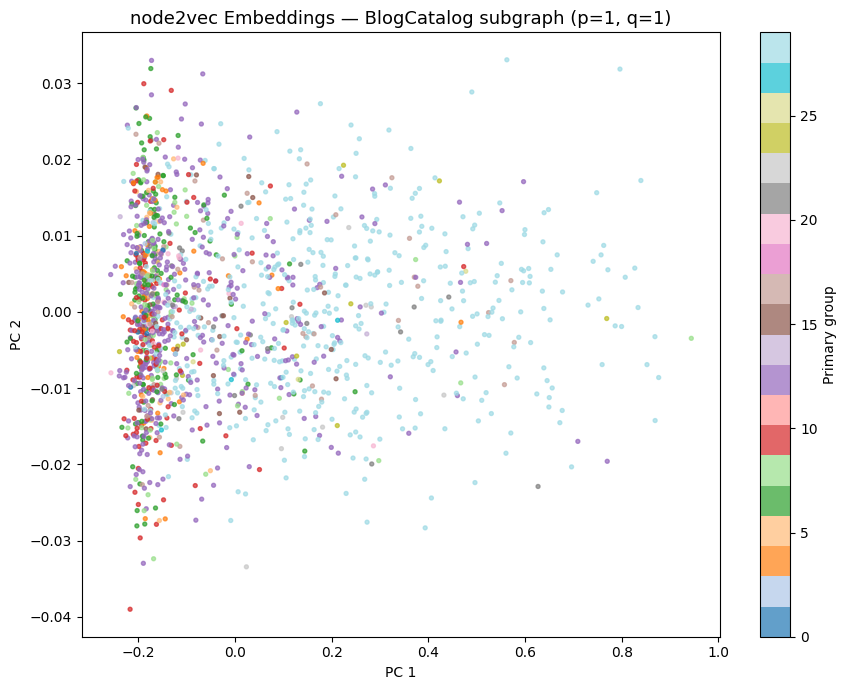

Figure saved to node2vec_pca.png


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

embeddings_vis = train_node2vec(G, p=1, q=1,
                                dimensions=DIMENSIONS,
                                walk_length=WALK_LENGTH,
                                num_walks=NUM_WALKS)

pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(embeddings_vis)

# Colour by first label group (nodes with no label shown in grey)
first_label = labels.argmax(axis=1).astype(float)
first_label[labels.sum(axis=1) == 0] = -1

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=first_label,
                cmap='tab20', s=8, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Primary group')
ax.set_title("node2vec Embeddings — BlogCatalog subgraph (p=1, q=1)", fontsize=13)
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
plt.tight_layout()
plt.savefig("node2vec_pca.png", dpi=150)
plt.show()
print("Figure saved to node2vec_pca.png")